In [2]:
import numpy as np
import cv2
import os
from glob import glob
import shutil

In [20]:
# --- CONFIGURATION ---
VIDEO_PATH = "./cam_calibration_vid.mp4"
OUTPUT_DIR = "./used_images"
CHECKERBOARD = (8, 6)
SQUARE_SIZE = 2.95  # In centimeters

shutil.rmtree(OUTPUT_DIR)
os.makedirs(OUTPUT_DIR)

In [21]:
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

objpoints = []
imgpoints = []

objp = np.zeros((CHECKERBOARD[0] * CHECKERBOARD[1], 3), np.float32)
objp[:, :2] = np.mgrid[0 : CHECKERBOARD[0], 0 : CHECKERBOARD[1]].T.reshape(-1, 2)
objp *= SQUARE_SIZE

In [22]:
frame_id = 0
saved_count = 0
gray_shape = None

for img_path in glob("./input_images/*.jpeg"):
    frame = cv2.imread(img_path)
    
    if frame is None:
        print(f"frame {img_path} is None")
        continue

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gray = cv2.equalizeHist(gray)

    gray_shape = gray.shape[::-1]

    found, corners = cv2.findChessboardCornersSB(gray, CHECKERBOARD)

    if found:
        objpoints.append(objp)

        # Refine the pixel coordinates to sub-pixel accuracy
        corners2 = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria)
        imgpoints.append(corners2)

        annotated_frame = frame.copy()
        cv2.drawChessboardCorners(annotated_frame, CHECKERBOARD, corners2, found)
        annotation_path = os.path.join(OUTPUT_DIR, f"frame_{frame_id:04d}_annotated.png")
        cv2.imwrite(annotation_path, annotated_frame)

        saved_count += 1
        print(f"-> Valid board found and saved: Frame {frame_id}")

    frame_id += 1

-> Valid board found and saved: Frame 4
-> Valid board found and saved: Frame 5
-> Valid board found and saved: Frame 6
-> Valid board found and saved: Frame 7
-> Valid board found and saved: Frame 8
-> Valid board found and saved: Frame 10
-> Valid board found and saved: Frame 11
-> Valid board found and saved: Frame 12
-> Valid board found and saved: Frame 13
-> Valid board found and saved: Frame 15
-> Valid board found and saved: Frame 17
-> Valid board found and saved: Frame 20
-> Valid board found and saved: Frame 21
-> Valid board found and saved: Frame 22
-> Valid board found and saved: Frame 23
-> Valid board found and saved: Frame 25
-> Valid board found and saved: Frame 27
-> Valid board found and saved: Frame 29
-> Valid board found and saved: Frame 31
-> Valid board found and saved: Frame 33
-> Valid board found and saved: Frame 34
-> Valid board found and saved: Frame 36
-> Valid board found and saved: Frame 39
-> Valid board found and saved: Frame 40
-> Valid board found 

In [23]:
print(f"\nFinished parsing video. Found {saved_count} valid frames.")

# --- CALIBRATION ---
if saved_count >= 10:
    print("Running camera calibration algorithm... (this might take a moment)")
    ret, K, dist, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints, gray_shape, None, None)

    print("\n=== Calibration Results ===")
    print(f"RMS Re-projection Error: {ret:.4f} pixels (Aim for < 1.0)")
    print("\nCamera Matrix (Intrinsic Parameters):\n", K)
    print("\nDistortion Coefficients:\n", dist)
else:
    print(
        f"\n[Warning]: Only found {saved_count} valid frames. You need at least 10-15 clear frames to get an accurate calibration. Try lowering your STEP_SIZE or moving the board more slowly in the video."
    )


Finished parsing video. Found 45 valid frames.
Running camera calibration algorithm... (this might take a moment)

=== Calibration Results ===
RMS Re-projection Error: 1.3761 pixels (Aim for < 1.0)

Camera Matrix (Intrinsic Parameters):
 [[1.49770202e+03 0.00000000e+00 4.38691766e+02]
 [0.00000000e+00 1.43516210e+03 9.18565271e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]

Distortion Coefficients:
 [[ 0.09600973 -1.13969576  0.00809251 -0.01848817  1.54268659]]


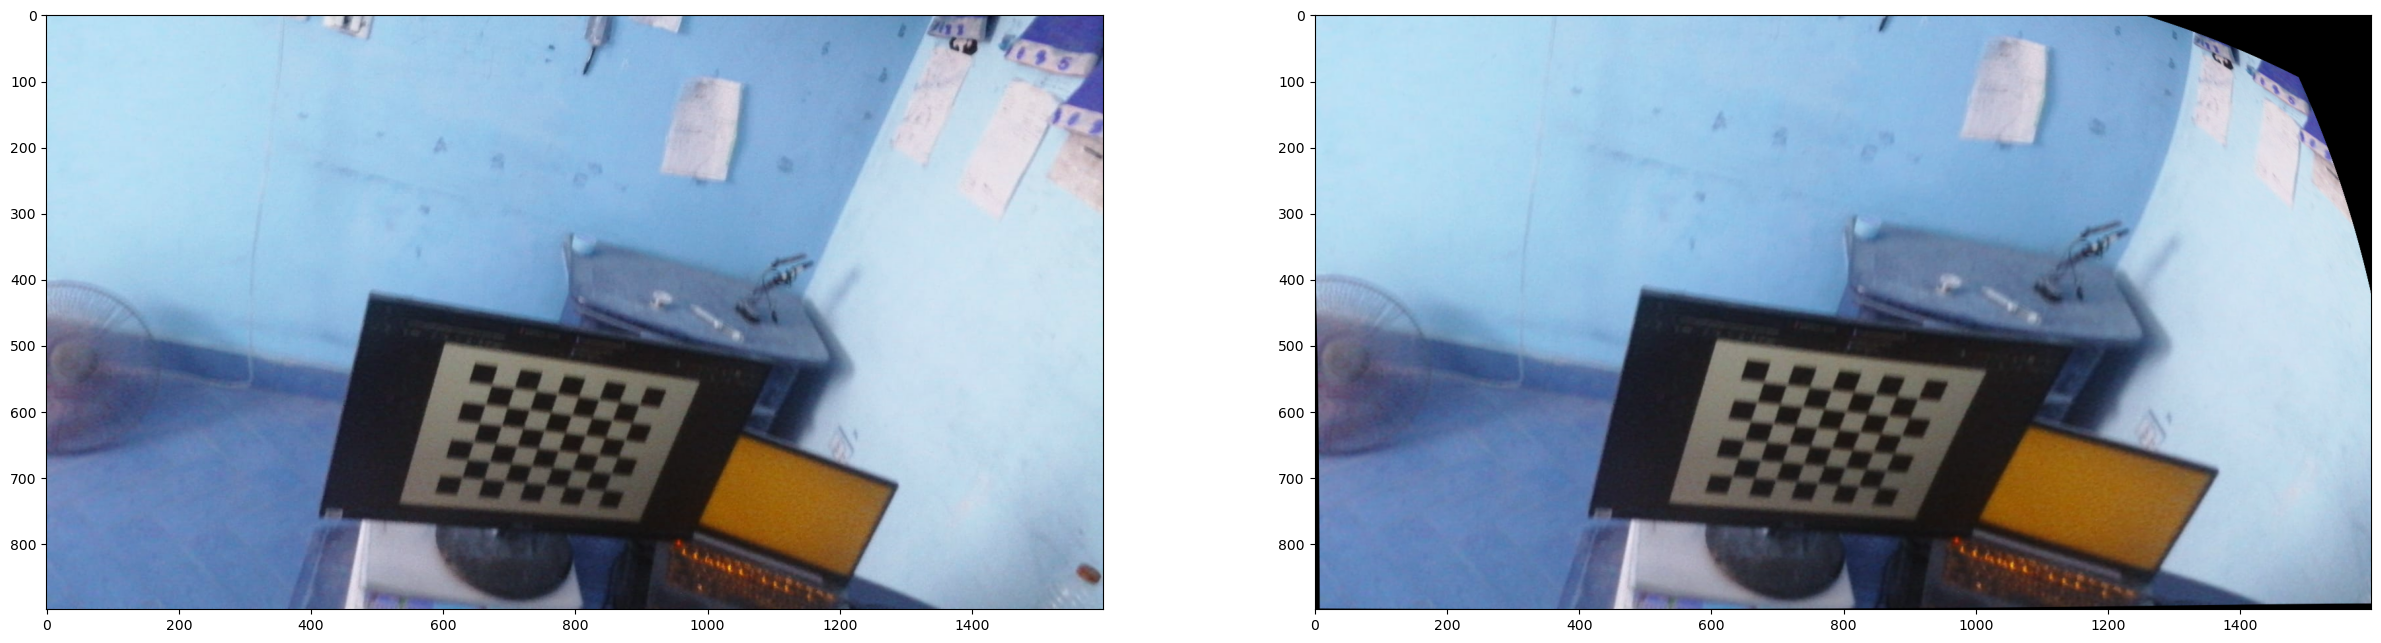

In [8]:
import matplotlib.pyplot as plt
K = np.array(
    [
        [1.49770202e03, 0.00000000e00, 4.38691766e02],
        [0.00000000e00, 1.43516210e03, 9.18565271e02],
        [0.00000000e00, 0.00000000e00, 1.00000000e00],
    ]
)
dist = np.array([0.09600973, -1.13969576, 0.00809251, -0.01848817, 1.54268659])

before = cv2.imread("./input_images/ZeyadCode-47-1780045012.jpeg")
after = cv2.undistort(before, K, dist)

plt.figure(figsize=(30, 30))
plt.subplot(121)
plt.imshow(before)

plt.subplot(122)
plt.imshow(after)